In [1]:
%load_ext autoreload

In [20]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

activity_col = "Activity_S3_1"

from scipy.ndimage import gaussian_filter1d


# 1. Function that averages the activities

In [27]:
# Load in the tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,349.798825,573.084946,461.441886
1,BasicArTh.2,Q6NQK2,11,31,51,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,470.700956,2417.845241,1444.273098
2,BasicArTh.3,Q6NQK2,21,41,61,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,867.654700,1328.781736,1098.218218


In [31]:
# Add ranges to use later for averaging
BasicArTh["range"] = [np.arange(s, e) for s, e in zip(BasicArTh["Start"], 
                                                      BasicArTh["End"])]
BasicArTh.head(3)

,Description,Other,Start,mid,End,tile,Activity_S3_1,Activity_S3_2,lib2_avg,range
0,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,349.798825,573.084946,461.441886,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,349.798825,573.084946,461.441886,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,BasicArTh.1,Q6NQK2,1,21,41,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,349.798825,573.084946,461.441886,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [29]:
# Expand using range
BasicArTh = BasicArTh.explode("range").reset_index(drop = True)
avg_activities = BasicArTh[["range", "Activity_S3_1"]].groupby(["range"]).mean().reset_index()
avg_activities = avg_activities.reset_index(drop = True)
avg_activities

,range,Activity_S3_1
0,1,349.798825
1,2,349.798825
2,3,349.798825
3,4,349.798825
4,5,349.798825
...,...,...
444,445,2221.196339
445,446,2221.196339
446,447,2221.196339
447,448,2221.196339


In [30]:
# Gaussian smoothing
avg_activities["smoothed_avg_activity"] = gaussian_filter1d(
        avg_activities["Activity_S3_1"], sigma=3  # Adjust 'sigma' for the smoothness
    )
avg_activities  

,range,Activity_S3_1,smoothed_avg_activity
0,1,349.798825,349.854653
1,2,349.798825,349.934281
2,3,349.798825,350.161224
3,4,349.798825,350.689619
4,5,349.798825,351.777587
...,...,...,...
444,445,2221.196339,2221.036683
445,446,2221.196339,2221.117028
446,447,2221.196339,2221.160527
447,448,2221.196339,2221.181318


<Axes: ylabel='smoothed_avg_activity'>

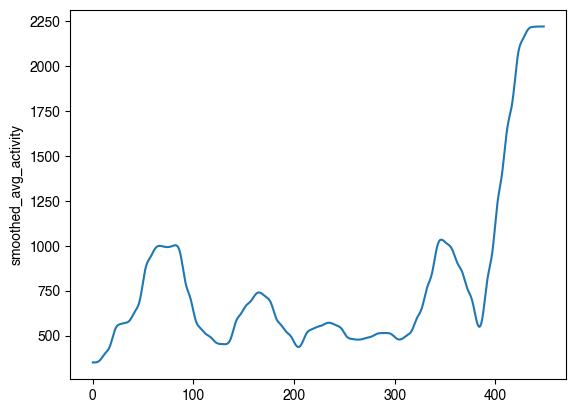

In [26]:
sns.lineplot(avg_activities["smoothed_avg_activity"])

In [32]:
# Putting it all together in a func
def return_avg_activities(name, pos_regex):
    
    # Load in the tiles
    BasicArTh = sog1_helpers.return_activities(name, pos_regex = pos_regex)
    
    # Add ranges to use later for averaging
    BasicArTh["range"] = [np.arange(s, e) for s, e in zip(BasicArTh["Start"], 
                                                          BasicArTh["End"])]

    # Expand using range
    BasicArTh = BasicArTh.explode("range").reset_index(drop = True)
    avg_activities = BasicArTh[["range", "Activity_S3_1"]].groupby(["range"]).mean().reset_index()
    avg_activities = avg_activities.reset_index(drop = True)
    
    # Gaussian smoothing
    avg_activities["smoothed_avg_activity"] = gaussian_filter1d(
            avg_activities["Activity_S3_1"], sigma=3  # Adjust 'sigma' for the smoothness
        )
    
    return avg_activities


In [33]:
return_avg_activities("BasicArTh", pos_regex = r'\.(\d+)')

,range,Activity_S3_1,smoothed_avg_activity
0,1,349.798825,349.854653
1,2,349.798825,349.934281
2,3,349.798825,350.161224
3,4,349.798825,350.689619
4,5,349.798825,351.777587
...,...,...,...
444,445,2221.196339,2221.036683
445,446,2221.196339,2221.117028
446,447,2221.196339,2221.160527
447,448,2221.196339,2221.181318


In [34]:
sog1_helpers.return_avg_activities("BasicArTh", pos_regex = r'\.(\d+)')

,range,Activity_S3_1,smoothed_avg_activity
0,1,349.798825,349.854653
1,2,349.798825,349.934281
2,3,349.798825,350.161224
3,4,349.798825,350.689619
4,5,349.798825,351.777587
...,...,...,...
444,445,2221.196339,2221.036683
445,446,2221.196339,2221.117028
446,447,2221.196339,2221.160527
447,448,2221.196339,2221.181318
